In [15]:
import os
import glob
import time
import re
from pathlib import Path
import numpy as np
import google.generativeai as genai
from google.api_core.exceptions import ResourceExhausted

In [16]:
# Load precomputed workload embeddings and filenames
import numpy as np
from pathlib import Path

project_root = Path("/Users/nisith/Desktop/FYP/E2ETune-AI4DB/Workload Clustering OLAP")
embeddings_path = project_root / "workload_embeddings.npy"
processed_files_path = project_root / "processed_files.txt"

embeddings = np.load(embeddings_path)
with processed_files_path.open() as f:
    filenames = [line.strip() for line in f if line.strip()]

print(f"Loaded embeddings shape: {embeddings.shape}")
print(f"Loaded {len(filenames)} filenames")
if embeddings.shape[0] != len(filenames):
    print("WARNING: number of embeddings does not match number of filenames")

Loaded embeddings shape: (989, 768)
Loaded 989 filenames


In [17]:
import umap
import hdbscan
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import numpy as np

# 1) Normalize embeddings
scaler = StandardScaler()
X = scaler.fit_transform(embeddings)

best_score = -1
best_result = None

n_neighbors_list = [5, 10, 20, 50]
min_dist_list = [0.0, 0.05, 0.1, 0.3]
umap_metrics = ['cosine', 'euclidean']
min_cluster_sizes = [2, 3, 4,  5, 6, 7, 8, 9, 10, 11,12,13,14,15]
min_samples_list = [1, 5]
selection_methods = ['leaf', 'eom']

for nn in n_neighbors_list:
    for md in min_dist_list:
        for um_metric in umap_metrics:
            reducer = umap.UMAP(
                n_neighbors=nn,
                min_dist=md,
                metric=um_metric,
                n_components=5,
                random_state=42
            )
            X_reduced = reducer.fit_transform(X)

            for mcs in min_cluster_sizes:
                for ms in min_samples_list:
                    for sel in selection_methods:
                        clusterer = hdbscan.HDBSCAN(
                            min_cluster_size=mcs,
                            min_samples=ms,
                            cluster_selection_method=sel,
                            metric='euclidean'
                        )
                        labels = clusterer.fit_predict(X_reduced)

                        valid_mask = labels != -1
                        if np.sum(valid_mask) < 2 or len(set(labels[valid_mask])) < 2:
                            continue

                        sil = silhouette_score(X_reduced[valid_mask], labels[valid_mask])

                        if sil > best_score:
                            best_score = sil
                            db = davies_bouldin_score(X_reduced[valid_mask], labels[valid_mask])
                            ch = calinski_harabasz_score(X_reduced[valid_mask], labels[valid_mask])
                            best_result = {
                                "X_reduced": X_reduced,
                                "labels": labels,
                                "sil": sil,
                                "db": db,
                                "ch": ch,
                                "params": {
                                    "n_neighbors": nn,
                                    "min_dist": md,
                                    "umap_metric": um_metric,
                                    "min_cluster_size": mcs,
                                    "min_samples": ms,
                                    "selection": sel,
                                },
                            }

print("Best params:", best_result["params"])
print(
    f"Metrics -> Silhouette: {best_result['sil']:.3f} | "
    f"Davies-Bouldin: {best_result['db']:.3f} | "
    f"Calinski-Harabasz: {best_result['ch']:.1f}"
)

X_reduced = best_result["X_reduced"]
labels = best_result["labels"]

# Create DataFrame
df = pd.DataFrame({'workload': filenames, 'cluster_id': labels})
df.head(10)

/Users/nisith/Desktop/FYP/E2ETune-AI4DB/Workload Clustering OLAP/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/nisith/Desktop/FYP/E2ETune-AI4DB/Workload Clustering OLAP/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/nisith/Desktop/FYP/E2ETune-AI4DB/Workload Clustering OLAP/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/nisith/Desktop/FYP/E2ETune-AI4DB/Workload Clustering OLAP/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/nisith/Desktop/FYP/E2ETune-AI4DB/Workload Clustering OLAP/clustering/

Best params: {'n_neighbors': 5, 'min_dist': 0.3, 'umap_metric': 'euclidean', 'min_cluster_size': 2, 'min_samples': 5, 'selection': 'eom'}
Metrics -> Silhouette: 0.722 | Davies-Bouldin: 0.210 | Calinski-Harabasz: 121.6


,workload,cluster_id
0,job_0.wg,1
1,job_1.wg,1
2,job_10.wg,1
3,job_100.wg,1
4,job_101.wg,1
5,job_102.wg,1
6,job_103.wg,1
7,job_104.wg,1
8,job_105.wg,1
9,job_106.wg,1


In [18]:
# Extract benchmark name from workload (e.g., "job_0.wg" -> "job")
df_with_benchmark = df.copy()
df_with_benchmark["benchmark"] = df_with_benchmark["workload"].str.extract(r"^([^_]+)")

# Print unique benchmarks in each cluster
for cluster_id, benchmarks in (
    df_with_benchmark.groupby("cluster_id")["benchmark"]
    .unique()
    .sort_index()
    .items()
):
    print(f"Cluster {cluster_id}: {sorted(benchmarks.tolist())}")

Cluster 0: ['tpch']
Cluster 1: ['job', 'ssb', 'tpcds', 'tpch']


/Users/nisith/Desktop/FYP/E2ETune-AI4DB/Workload Clustering OLAP/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


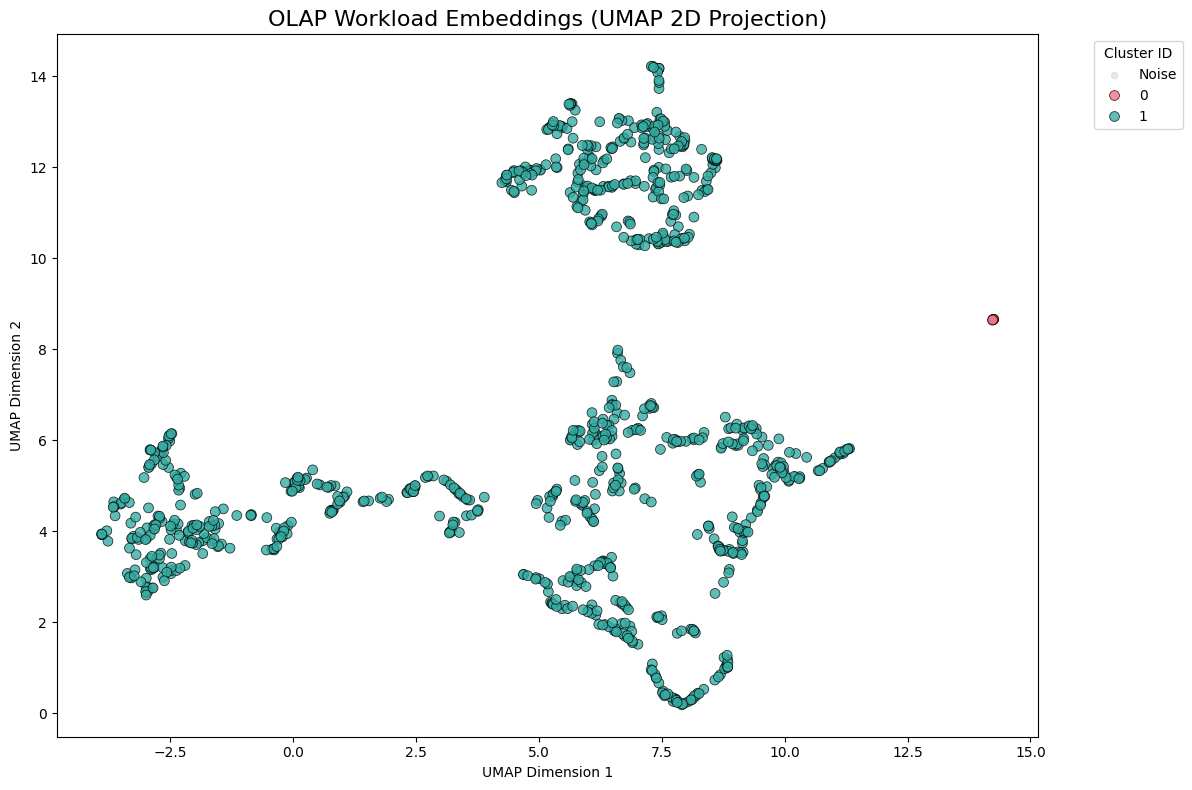

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a 2D projection strictly for visualization
visual_mapper = umap.UMAP(n_neighbors=5, min_dist=0.05, metric='cosine', n_components=2, random_state=42)
X_2d = visual_mapper.fit_transform(embeddings)

# Prepare plot
plt.figure(figsize=(12, 8))
palette = sns.color_palette('husl', len(set(labels)) - (1 if -1 in labels else 0))

# Plot noise (-1) in light grey
noise_mask = labels == -1
plt.scatter(X_2d[noise_mask, 0], X_2d[noise_mask, 1], c='lightgrey', s=20, alpha=0.5, label='Noise')

# Plot clusters
clustered_mask = labels != -1
sns.scatterplot(
    x=X_2d[clustered_mask, 0], 
    y=X_2d[clustered_mask, 1],
    hue=labels[clustered_mask],
    palette=palette,
    s=50,
    edgecolor='k',
    alpha=0.8,
    legend='full'
)

plt.title("OLAP Workload Embeddings (UMAP 2D Projection)", fontsize=16)
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Cluster ID")
plt.tight_layout()
plt.show()

In [20]:
import re
import numpy as np
import pandas as pd
import umap
import hdbscan
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# ── Build a DataFrame linking each filename → its embedding index & benchmark ──
filenames_arr = np.array(filenames)
benchmark_names = np.array([re.match(r"^([^_]+)", fn).group(1) for fn in filenames_arr])
unique_benchmarks = sorted(set(benchmark_names))
print(f"Benchmarks found: {unique_benchmarks}\n")

per_benchmark_results = {}

for bm in unique_benchmarks:
    idx = np.where(benchmark_names == bm)[0]
    if len(idx) < 5:
        print(f"[{bm}]  skipped — only {len(idx)} workloads (need ≥ 5)\n")
        continue

    bm_embeddings = embeddings[idx]
    bm_filenames  = filenames_arr[idx]

    # Normalise
    X_bm = StandardScaler().fit_transform(bm_embeddings)

    # ── Grid search identical to the global cell ──────────────────────────────
    n_neighbors_list   = [5, 10, 20, min(50, len(idx) - 1)]
    min_dist_list      = [0.0, 0.05, 0.1, 0.3]
    umap_metrics       = ['cosine', 'euclidean']
    min_cluster_sizes  = list(range(2, min(15, len(idx) // 2) + 1))
    min_samples_list   = [1, 5]
    selection_methods  = ['leaf', 'eom']
    n_components       = min(5, len(idx) - 1)

    best_sil    = -1
    best_res_bm = None

    for nn in n_neighbors_list:
        if nn >= len(idx):
            continue
        for md in min_dist_list:
            for um_metric in umap_metrics:
                reducer = umap.UMAP(
                    n_neighbors=nn, min_dist=md, metric=um_metric,
                    n_components=n_components, random_state=42
                )
                X_red = reducer.fit_transform(X_bm)

                for mcs in min_cluster_sizes:
                    for ms in min_samples_list:
                        for sel in selection_methods:
                            clusterer = hdbscan.HDBSCAN(
                                min_cluster_size=mcs, min_samples=ms,
                                cluster_selection_method=sel, metric='euclidean'
                            )
                            lbl = clusterer.fit_predict(X_red)
                            vm  = lbl != -1
                            if np.sum(vm) < 2 or len(set(lbl[vm])) < 2:
                                continue
                            sil = silhouette_score(X_red[vm], lbl[vm])
                            if sil > best_sil:
                                best_sil = sil
                                best_res_bm = {
                                    "X_red": X_red, "labels": lbl,
                                    "sil": sil,
                                    "db":  davies_bouldin_score(X_red[vm], lbl[vm]),
                                    "ch":  calinski_harabasz_score(X_red[vm], lbl[vm]),
                                    "params": dict(
                                        n_neighbors=nn, min_dist=md, umap_metric=um_metric,
                                        min_cluster_size=mcs, min_samples=ms, selection=sel
                                    ),
                                    "filenames": bm_filenames,
                                    "idx": idx,
                                }

    if best_res_bm is None:
        print(f"[{bm}]  no valid clustering found — all runs produced < 2 clusters\n")
        continue

    per_benchmark_results[bm] = best_res_bm
    lbl    = best_res_bm["labels"]
    n_cls  = len(set(lbl)) - (1 if -1 in lbl else 0)
    noise  = int(np.sum(lbl == -1))
    print(f"[{bm}]  workloads={len(idx)}  clusters={n_cls}  noise={noise}")
    print(f"         params : {best_res_bm['params']}")
    print(f"         metrics: Sil={best_res_bm['sil']:.3f}  DB={best_res_bm['db']:.3f}  CH={best_res_bm['ch']:.1f}\n")

print("Done.")


Benchmarks found: [np.str_('job'), np.str_('ssb'), np.str_('tpcds'), np.str_('tpch')]



/Users/nisith/Desktop/FYP/E2ETune-AI4DB/Workload Clustering OLAP/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/nisith/Desktop/FYP/E2ETune-AI4DB/Workload Clustering OLAP/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/nisith/Desktop/FYP/E2ETune-AI4DB/Workload Clustering OLAP/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/nisith/Desktop/FYP/E2ETune-AI4DB/Workload Clustering OLAP/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/nisith/Desktop/FYP/E2ETune-AI4DB/Workload Clustering OLAP/clustering/

[job]  workloads=244  clusters=15  noise=58
         params : {'n_neighbors': 5, 'min_dist': 0.0, 'umap_metric': 'cosine', 'min_cluster_size': 4, 'min_samples': 5, 'selection': 'leaf'}
         metrics: Sil=0.680  DB=0.405  CH=909.4



/Users/nisith/Desktop/FYP/E2ETune-AI4DB/Workload Clustering OLAP/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/nisith/Desktop/FYP/E2ETune-AI4DB/Workload Clustering OLAP/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/nisith/Desktop/FYP/E2ETune-AI4DB/Workload Clustering OLAP/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/nisith/Desktop/FYP/E2ETune-AI4DB/Workload Clustering OLAP/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/nisith/Desktop/FYP/E2ETune-AI4DB/Workload Clustering OLAP/clustering/

[ssb]  workloads=240  clusters=11  noise=29
         params : {'n_neighbors': 5, 'min_dist': 0.0, 'umap_metric': 'cosine', 'min_cluster_size': 2, 'min_samples': 5, 'selection': 'eom'}
         metrics: Sil=0.694  DB=0.393  CH=585.4



/Users/nisith/Desktop/FYP/E2ETune-AI4DB/Workload Clustering OLAP/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/nisith/Desktop/FYP/E2ETune-AI4DB/Workload Clustering OLAP/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/nisith/Desktop/FYP/E2ETune-AI4DB/Workload Clustering OLAP/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/nisith/Desktop/FYP/E2ETune-AI4DB/Workload Clustering OLAP/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/nisith/Desktop/FYP/E2ETune-AI4DB/Workload Clustering OLAP/clustering/

[tpcds]  workloads=233  clusters=6  noise=89
         params : {'n_neighbors': 10, 'min_dist': 0.05, 'umap_metric': 'euclidean', 'min_cluster_size': 9, 'min_samples': 5, 'selection': 'leaf'}
         metrics: Sil=0.638  DB=0.527  CH=393.1



/Users/nisith/Desktop/FYP/E2ETune-AI4DB/Workload Clustering OLAP/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/nisith/Desktop/FYP/E2ETune-AI4DB/Workload Clustering OLAP/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/nisith/Desktop/FYP/E2ETune-AI4DB/Workload Clustering OLAP/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/nisith/Desktop/FYP/E2ETune-AI4DB/Workload Clustering OLAP/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/nisith/Desktop/FYP/E2ETune-AI4DB/Workload Clustering OLAP/clustering/

[tpch]  workloads=272  clusters=4  noise=0
         params : {'n_neighbors': 5, 'min_dist': 0.0, 'umap_metric': 'cosine', 'min_cluster_size': 2, 'min_samples': 5, 'selection': 'eom'}
         metrics: Sil=0.801  DB=0.250  CH=1579.9

Done.


In [21]:

# ── Per-benchmark cluster membership table ─────────────────────────────────────
rows = []
for bm, res in per_benchmark_results.items():
    lbl = res["labels"]
    fns = res["filenames"]
    for fn, cl in zip(fns, lbl):
        rows.append({"benchmark": bm, "workload": fn, "cluster_id": int(cl)})

df_per_bm = pd.DataFrame(rows).sort_values(["benchmark", "cluster_id", "workload"]).reset_index(drop=True)

# Summary counts
summary = (
    df_per_bm.groupby(["benchmark", "cluster_id"])
    .size()
    .reset_index(name="count")
)
print(summary.to_string(index=False))


benchmark  cluster_id  count
      job          -1     58
      job           0     14
      job           1     18
      job           2      6
      job           3     13
      job           4     42
      job           5      8
      job           6     11
      job           7     14
      job           8     13
      job           9      7
      job          10      6
      job          11      9
      job          12     12
      job          13      7
      job          14      6
      ssb          -1     29
      ssb           0     69
      ssb           1      8
      ssb           2     34
      ssb           3     35
      ssb           4      7
      ssb           5     12
      ssb           6     10
      ssb           7      8
      ssb           8      9
      ssb           9      5
      ssb          10     14
    tpcds          -1     89
    tpcds           0     24
    tpcds           1     38
    tpcds           2     14
    tpcds           3     25
    tpcds     

/Users/nisith/Desktop/FYP/E2ETune-AI4DB/Workload Clustering OLAP/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/nisith/Desktop/FYP/E2ETune-AI4DB/Workload Clustering OLAP/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/nisith/Desktop/FYP/E2ETune-AI4DB/Workload Clustering OLAP/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/nisith/Desktop/FYP/E2ETune-AI4DB/Workload Clustering OLAP/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


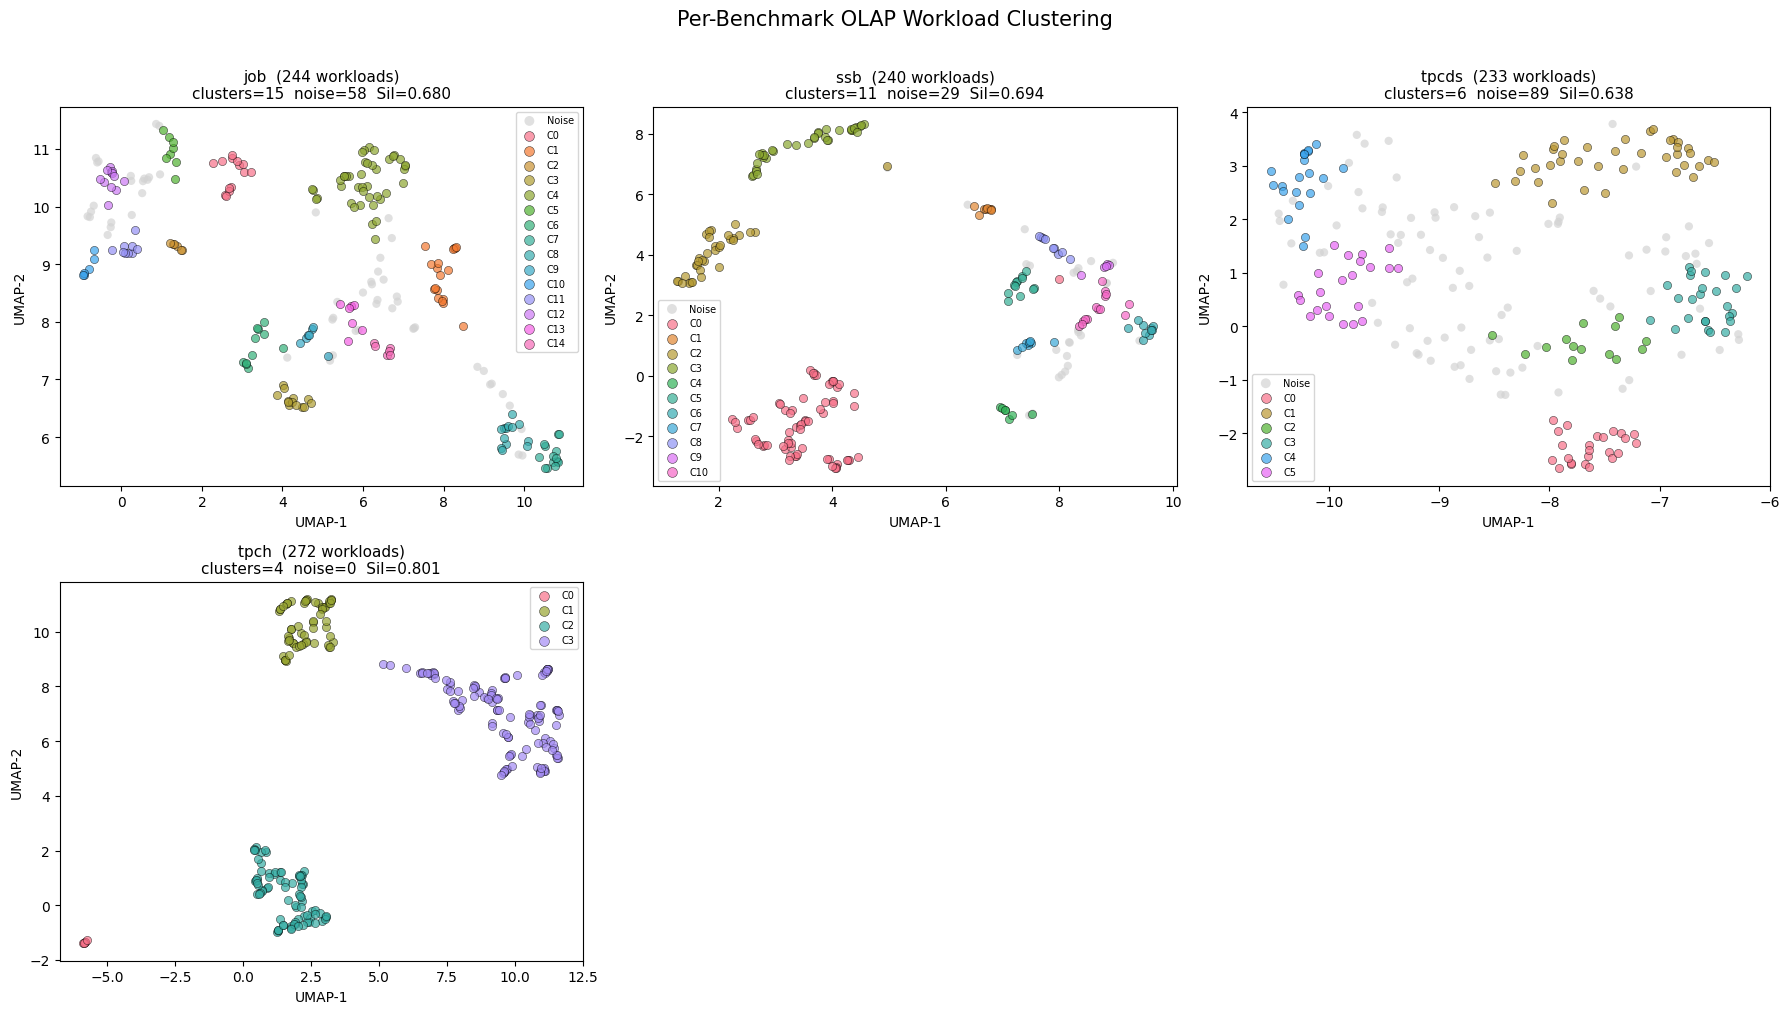

In [22]:

# ── 2-D UMAP scatter plot for each benchmark ──────────────────────────────────
n_bms = len(per_benchmark_results)
ncols = min(3, n_bms)
nrows = (n_bms + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes = np.array(axes).flatten()   # always a flat array

for ax_i, (bm, res) in enumerate(sorted(per_benchmark_results.items())):
    ax   = axes[ax_i]
    lbl  = res["labels"]
    fns  = res["filenames"]

    # 2-D projection purely for visualisation
    p2d  = res["params"]
    vis  = umap.UMAP(
        n_neighbors=p2d["n_neighbors"], min_dist=p2d["min_dist"],
        metric=p2d["umap_metric"], n_components=2, random_state=42
    )
    X_bm  = StandardScaler().fit_transform(embeddings[res["idx"]])
    X2d   = vis.fit_transform(X_bm)

    unique_cls = sorted(set(lbl))
    pal = sns.color_palette("husl", sum(c != -1 for c in unique_cls))
    color_map = {}
    ci = 0
    for c in unique_cls:
        color_map[c] = "lightgrey" if c == -1 else pal[ci]
        if c != -1:
            ci += 1

    for c in unique_cls:
        mask = lbl == c
        label = "Noise" if c == -1 else f"C{c}"
        ax.scatter(X2d[mask, 0], X2d[mask, 1],
                   c=[color_map[c]], s=35, alpha=0.7,
                   edgecolors='k' if c != -1 else 'none',
                   linewidths=0.4, label=label)

    n_cls   = sum(c != -1 for c in unique_cls)
    n_noise = int(np.sum(lbl == -1))
    ax.set_title(
        f"{bm}  ({len(fns)} workloads)\n"
        f"clusters={n_cls}  noise={n_noise}  Sil={res['sil']:.3f}",
        fontsize=11
    )
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")
    ax.legend(fontsize=7, markerscale=1.2, loc="best")

# Hide any unused subplots
for ax_j in range(ax_i + 1, len(axes)):
    axes[ax_j].set_visible(False)

plt.suptitle("Per-Benchmark OLAP Workload Clustering", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()
